Colab Link
https://colab.research.google.com/drive/1LcFNm99X5BxK3fLdtjs8CztoTqL5CIpj#scrollTo=xXOkhAe7A1I1

## Content

- **Dimensionality Reduction**
    - Curse of Dimensionality

- **PCA**
    - What is PCA?
    - Analogy
    - Working
    - Variation explained
    - Reduce Dimensionality
    - Code walkthrough

- **t-SNE**
    - Calculating probabilities
    - Similarity matrix
    - Random initialization
    - Crowding problem
    - Perplexity
    - tsne limitation

Let's say we have a very big set of columns (around 1000). These days, having this many number of features is very common in data industry.

> #### Q. What's the problem with having this many columns?

### Curse of Dimensionality
![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/066/720/original/img.jpeg?1709189848)

### Curse of dimensionality

The Curse of Dimensionality sounds like something straight out of a pirate movie but what it really refers to is when your data has too many features.


It is well known that ML/DL algorithms need a large amount of data to learn invariance, patterns, and representations. If this data comprises a large number of features, this can lead to the curse of dimensionality.

- too many dimensions causes every observation in your dataset to appear equidistant from all the others.
- If the distances are all approximately equal, then all the observations appear equally alike (as well as equally different), and no meaningful relations can be formed.
- If the data has a lot of sparse features then the space and computational complexity increase. The model trained on sparse data performed poorly in the test dataset.
- In other words, the model during the training learns noise and they are not able to generalize well.



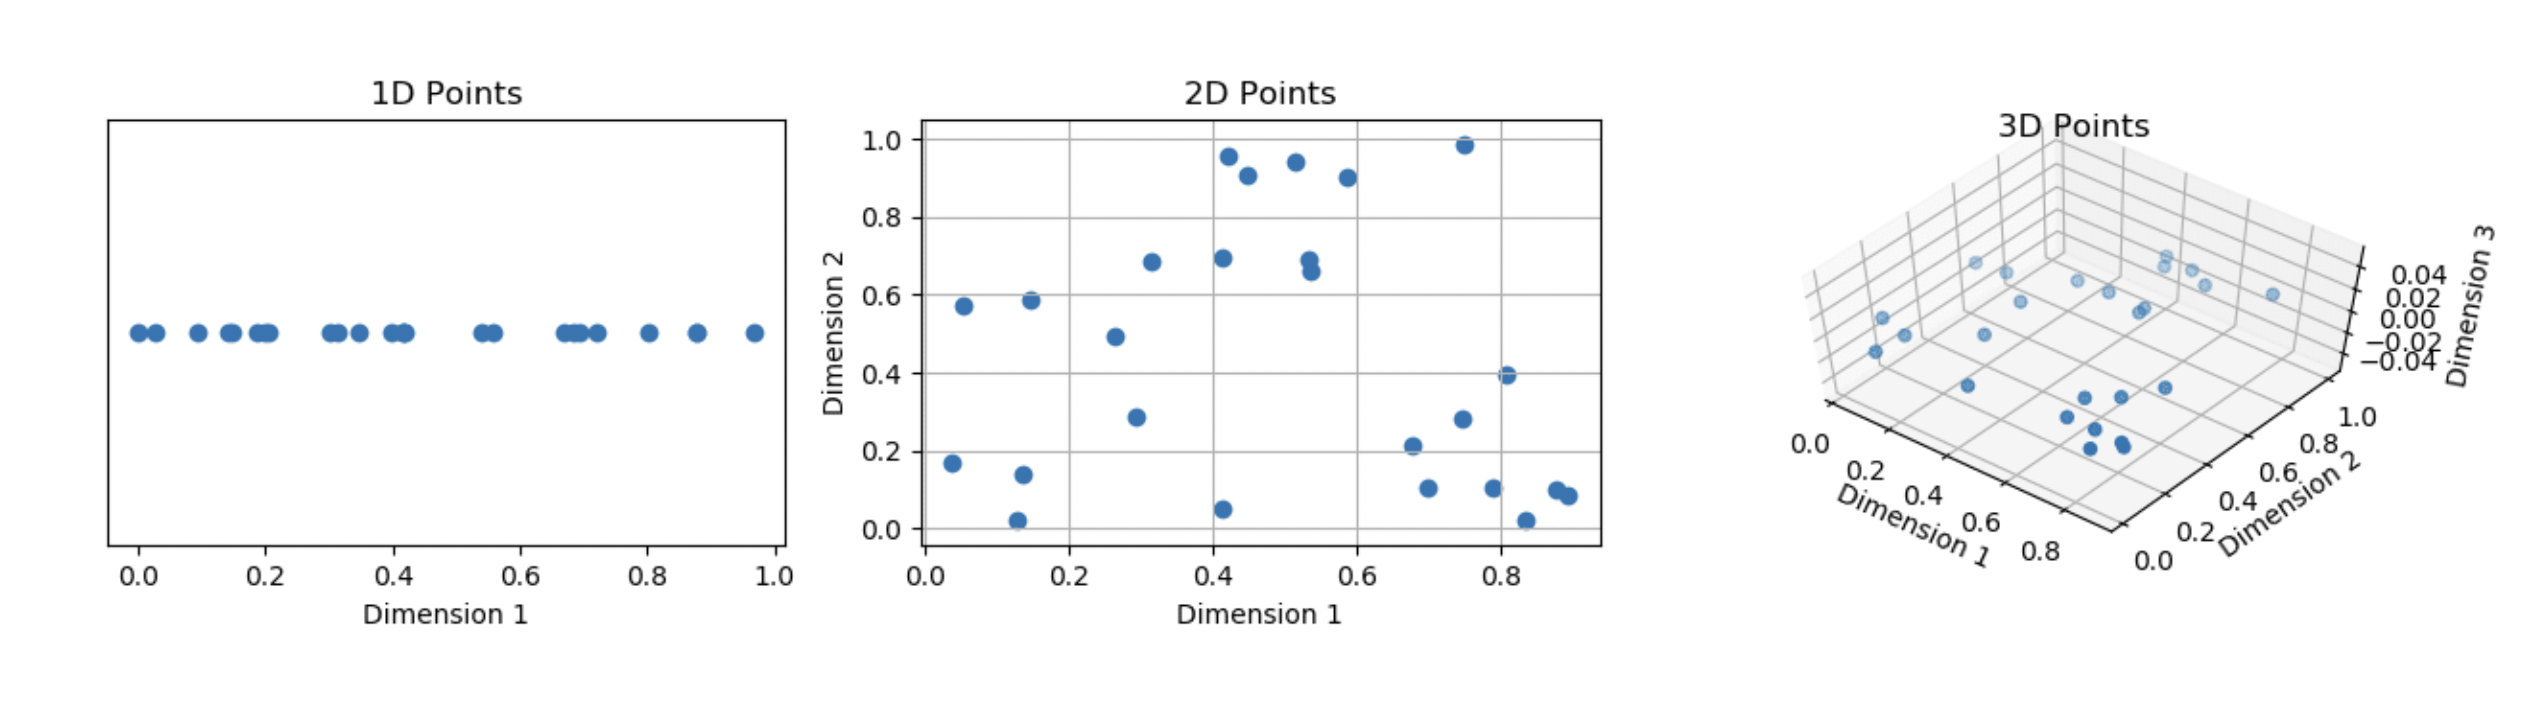

> #### Q. What's the solution then?

### Dimensionality Reduction

The higher the number of features, the harder it gets to visualize the training set and then work on it. Sometimes, most of these features are correlated, and hence redundant. redundant information makes modeling complicated. Furthermore, interpreting and understanding the data by visualization gets difficult because of the high dimensionality.This is where dimensionality reduction algorithms come into play

* Dimensionality reduction is the process of reducing the number of variables in high-dimensional data while keeping as much of the variability in the original data as possible.

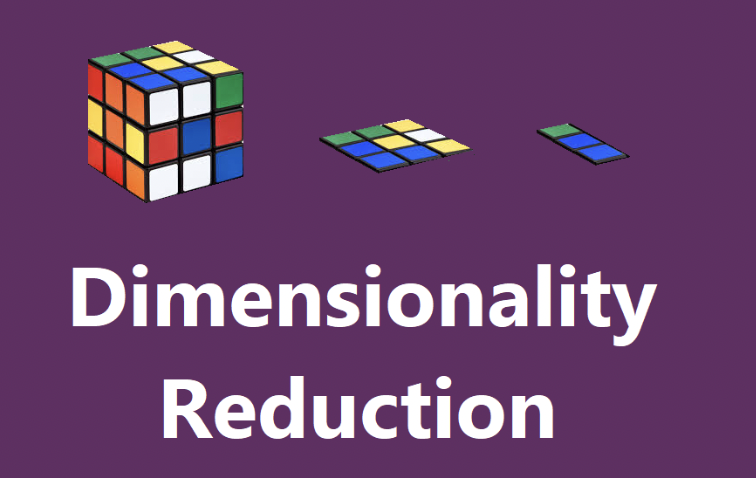

> #### Q. How do we reduce the dimensions?

For dimensionality reduction, we have techniques like PCA, t-SNE, etc.

**NOTE** : </br>
When you reduce the no. of columns, you might end up losing some valuable information.

## PCA

### What Is Principal Component Analysis?
Principal Component Analysis, or PCA, is a dimensionality-reduction method that is often used to reduce the dimensionality of large data sets, by transforming a large set of variables into a smaller one that still contains most of the information in the large set.

- Principal component analysis (PCA) is an unsupervised machine learning technique. Perhaps the most popular use of principal component analysis is dimensionality reduction, it can also be used as a data preparation technique, and to help visualize data. With the data visualized, it is easier for us to get some insights and decide on the next step in our machine learning models.

- Reducing the number of variables of a data set naturally comes at the expense of accuracy, but the trick in dimensionality reduction is to trade a little accuracy for simplicity. Because smaller data sets are easier to explore and visualize and make analyzing data much easier and faster for machine learning algorithms without extraneous variables to process.

</br>

<img src='https://drive.google.com/uc?id=1SsiyoWOEPc7yO2BQvvNHBk_inZZeVSFK' height='300' width='800'>


### Analogy

Finding the time to read a 1000-pages book is a not easy, takes time and very difficult to understand if the information is scattered throughout.

 Wouldn’t it be nice if we can summarize the most important points in just 2 or 3 pages so that the information is easily digestible ? We may lose some information in the process, but hey, at least we get the big picture.


**PCA is simple — reduce the number of variables of a data set, while preserving as much information as possible**

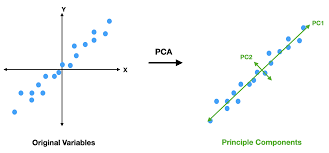

### How pca works

We can’t write a book summary if we haven’t read or understood the content of the book.

PCA works the same way — understand, then summarize.

It is a linear transformation that chooses a new coordinate system for the data set such that greatest variance by any projection of the data set comes to lie on the first axis (then called the first principal component), the second greatest variance on the second axis,and so on.


- ie: we want to transform the data in such a way that the first principal component explains the most about the data, followed by the second and so on, such that we can get the most information using fewer dimensions



> instructor note:
- theres a lot of maths that goes behind how actually pca works, but going into that depth is out of scope and syllabus, students can use these links if they want to get indepth baground understanding
- https://towardsdatascience.com/the-mathematics-behind-principal-component-analysis-fff2d7f4b643
- https://royalsocietypublishing.org/doi/10.1098/rsta.2015.0202#:~:text=Principal%20component%20analysis%20(PCA)%20is,variables%20that%20successively%20maximize%20variance.

## Variance Example


### Example 1

</br>

**Q. Which feature is providing more information?**

</br>

<img src='https://drive.google.com/uc?id=14wOO1-UrrZQ5HjUqf1lUDNZIHJxhQV7b' height='300' width='500'>

</br>

Ans: $f_1$ </br>
Since the value of $f_2$ is same for all the records.

</br>

<img src='https://drive.google.com/uc?id=1Wgn9aDfE8N2M8VhEwQOqbQowuCZBEZgV' height='300' width='500'>

</br>

### Example 2

We are going to take an other example of cars to understand how pca understands the data and works

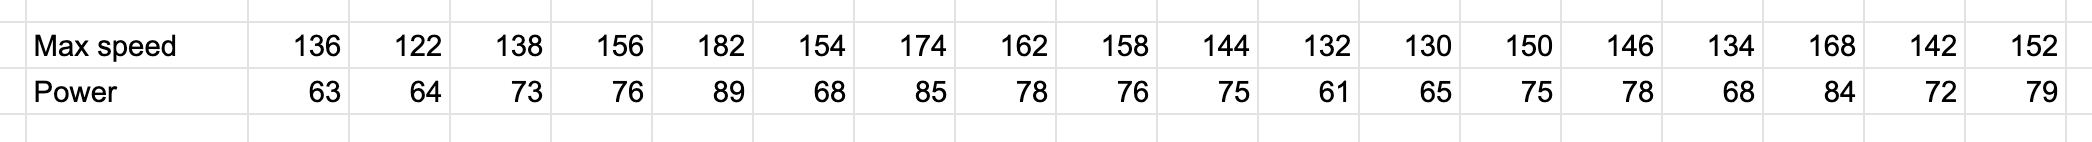

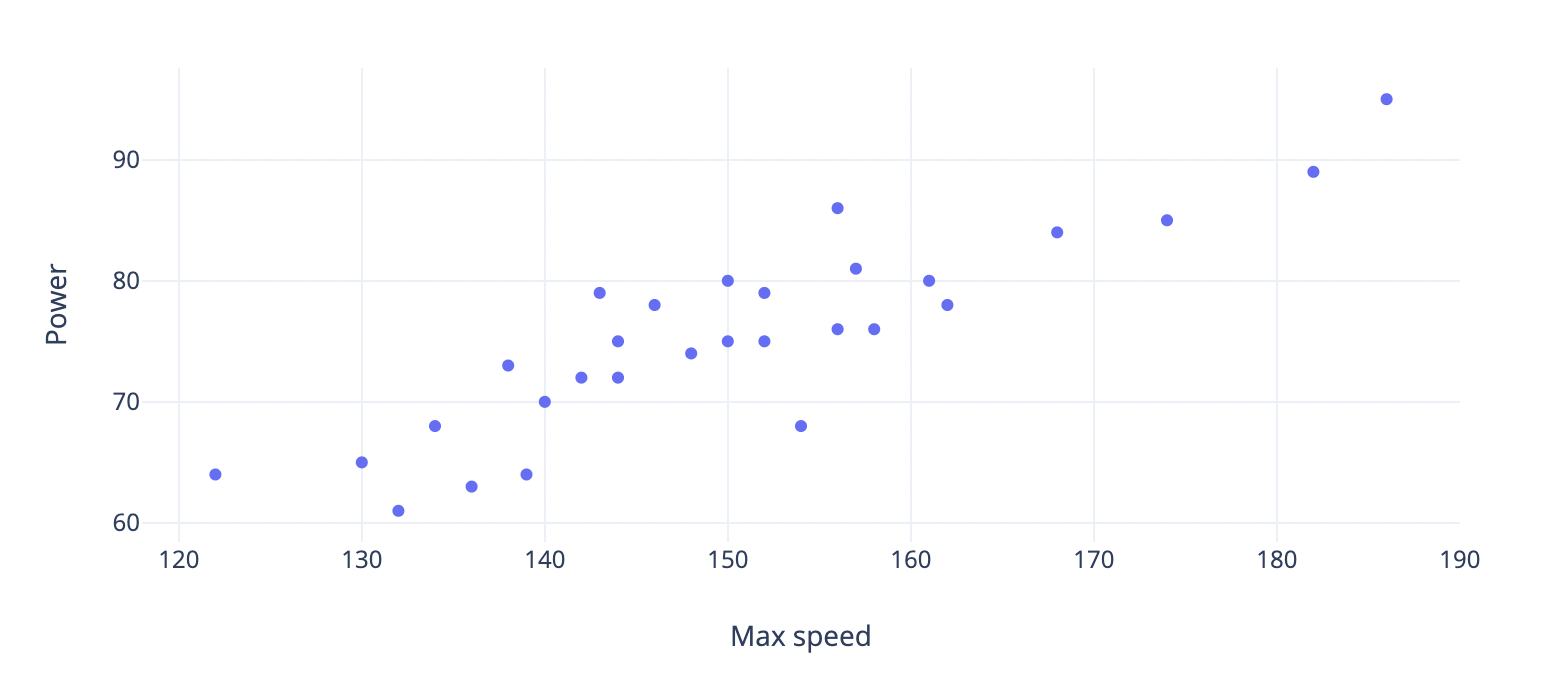

- this is a 2d plot, what if we just want one dimension to represent this data
- what is the best feature to choose?

We can choose power or max speed as both of them have good amount of variance.

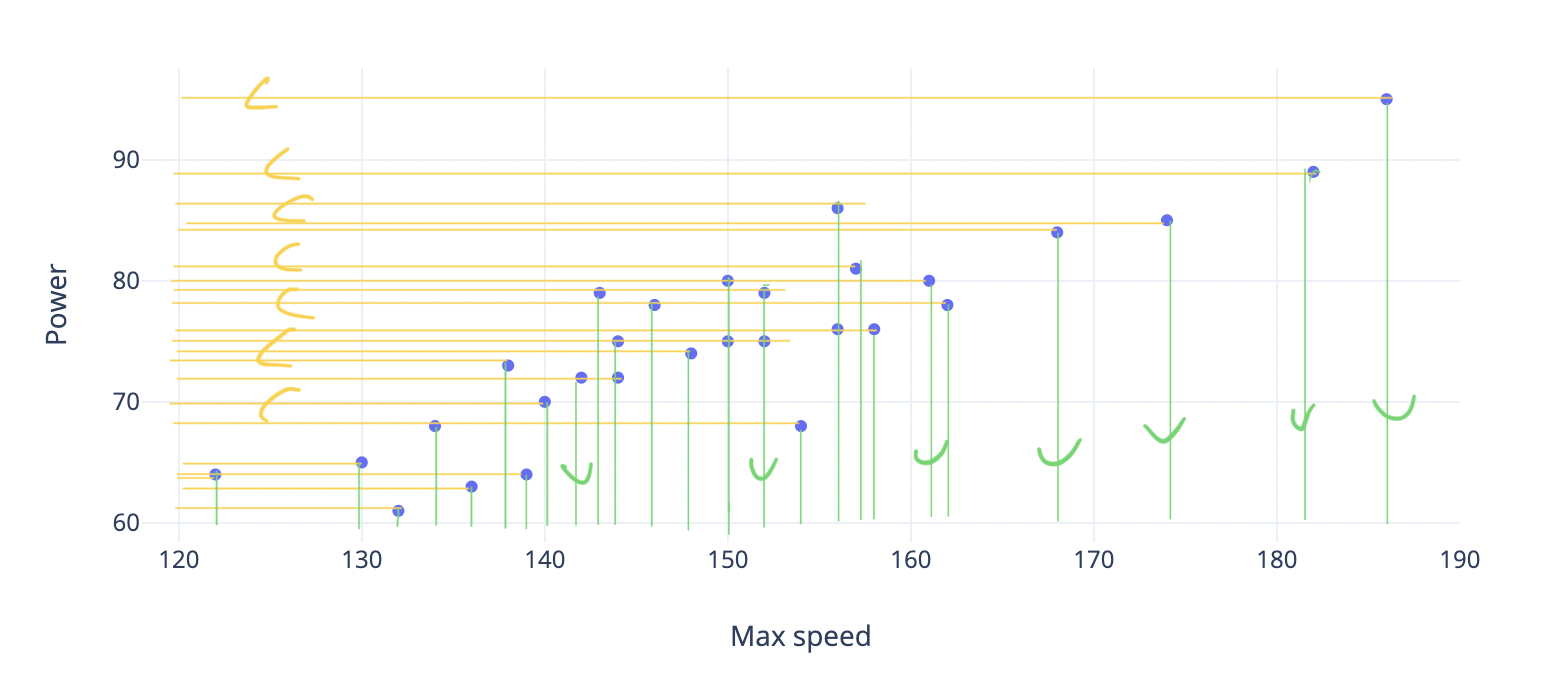

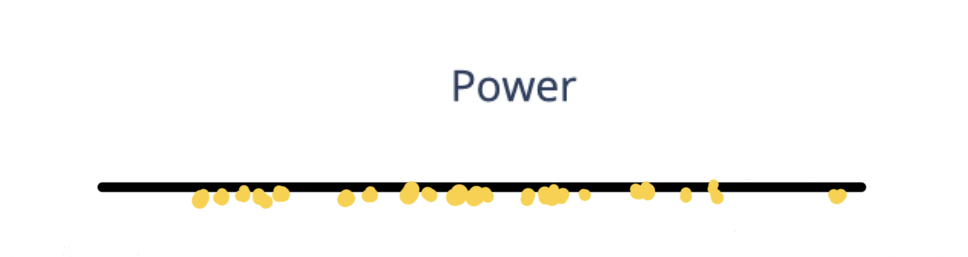

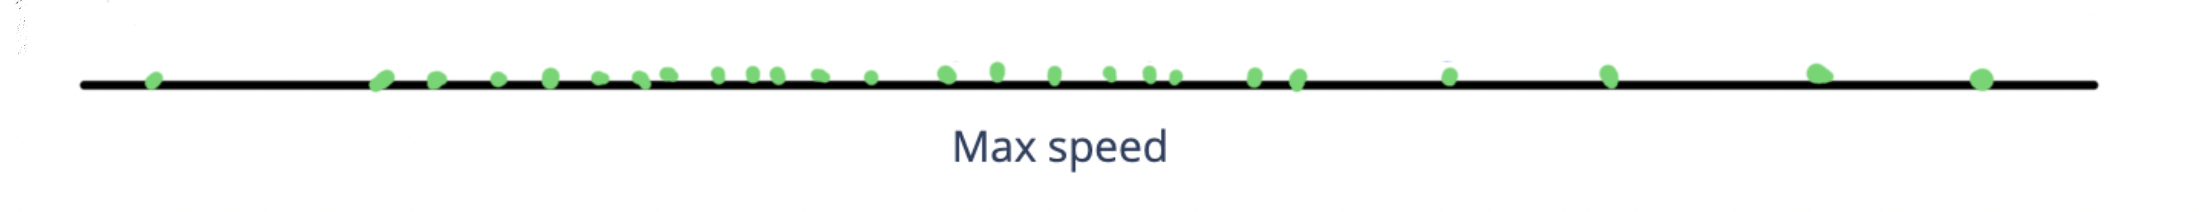

Which of the two features has the maximum varaince ?
- After projecting them onto their respective axis we see that max speed has the maximum variance.

If we were to choose only one feature to represet the data in 1D which feature would we choose and why?
- We would go with Max speed as it has most of the variance along this feature and we can get relative information better in case of max speed.

Can we do better? can we find a new feature that will help us because let say we go with max speed and choose to drop power we are losing too much of the information.
- We can create a new feature where we rotate the axis such that the new feature vector f2' lies as shown below.
- **Mention linear combinatin**

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/067/238/original/download.png?1709581191)

Now if we were to projects the points along this new axis we can see that the variance aling the f2' axis is the maimum and along f1' is not that great as many points will be projected on to same place.

But how is pca going to create such a feature? which not a line which is very close to f2' shown above can be the best line?
-  it will try to find a line such that its sum of square distance is maximum for all the points or simply the best fit line,
we'll see that bellow

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/067/239/original/download_%281%29.png?1709581435)

consider a single point

- let the distance from from origin to that point be A, which will not change
- now to see which line is better we create two lines green and red
- then project the point on those lines, we get a right angle at the spot where the p=rojection of the point meets the line
- remember the pythagoras theorem in a right angle triangle  $hypotenuse^2 = perpendicular^2 + base^2$
- because the hypotenuse ie: A remains costant if either the base or perpendicular increases then other decreases.
- we want to maximize the base in our case that is B for the green line or C for the red line
- B and C are the squared distance for those lines.
- it will be maximum when the line passes through the point


 now in case of multiple points
- we want to find a line such that the sum of all squared distance is maximum.
- the line will be rotated at different angles and the line which has the highest sum of squared distances $SS(distance)$ will be choosen
- that will be the line that explains the data in the most effective way



PCA will find a new line or axis that has the highest squared distances for all points

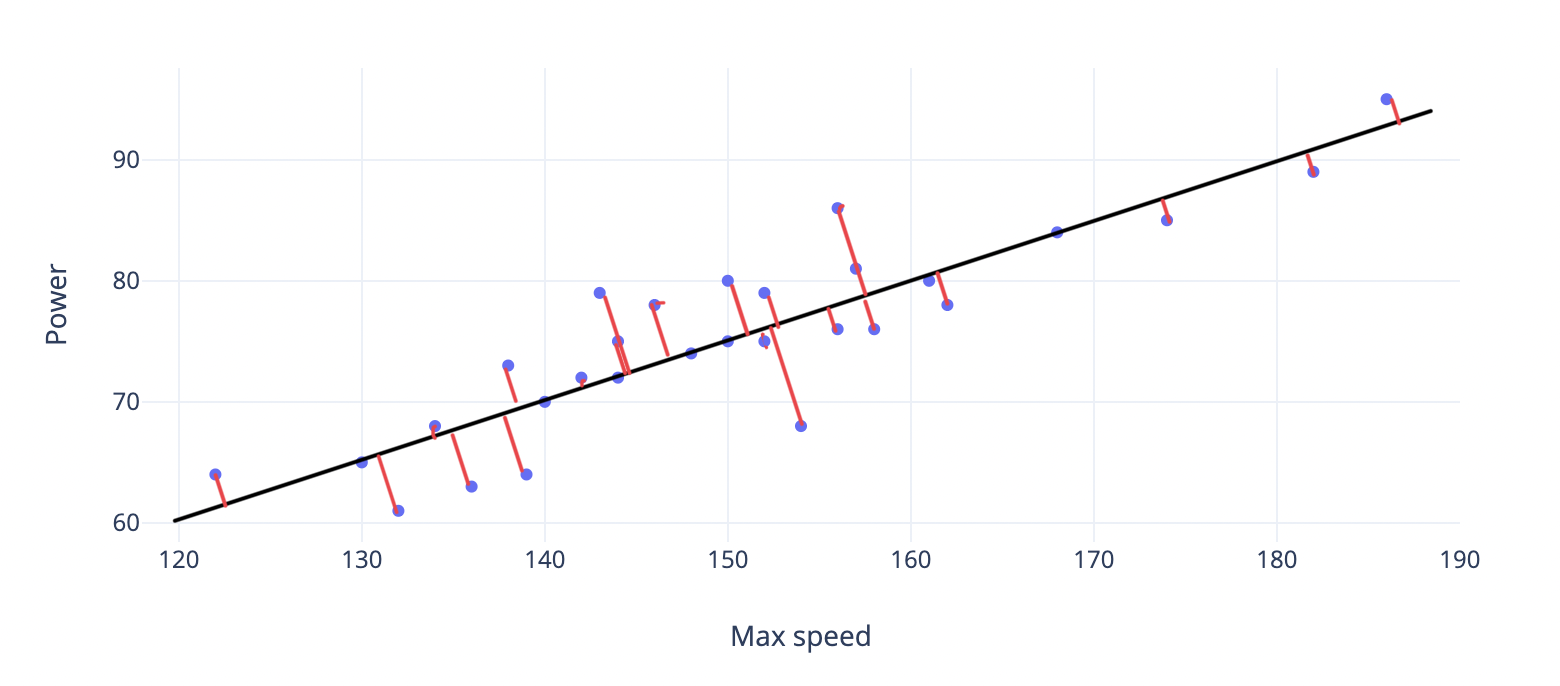

we can clearly see that this projection of the points on this line explains the data better, there is more relative information in this data than the two previous features


this line is the PC1 or the principal component 1 for this data

- this is a feature that is made up from the combinatin of both max speed and the power

We got the pc1 and have the data points projected onto it, but could we explain or show all the details regarding the data
- after projection we have distorted the actual distances between the points.
- some points for eg: consider points between 150 and 160 max speed on the opposite side of the pc1 have a large pairwise distance, but after projection, the distance will be comparitively less
- also not all pairwise distance gets affected equally.

So how can we solve this
- introduce another principal component

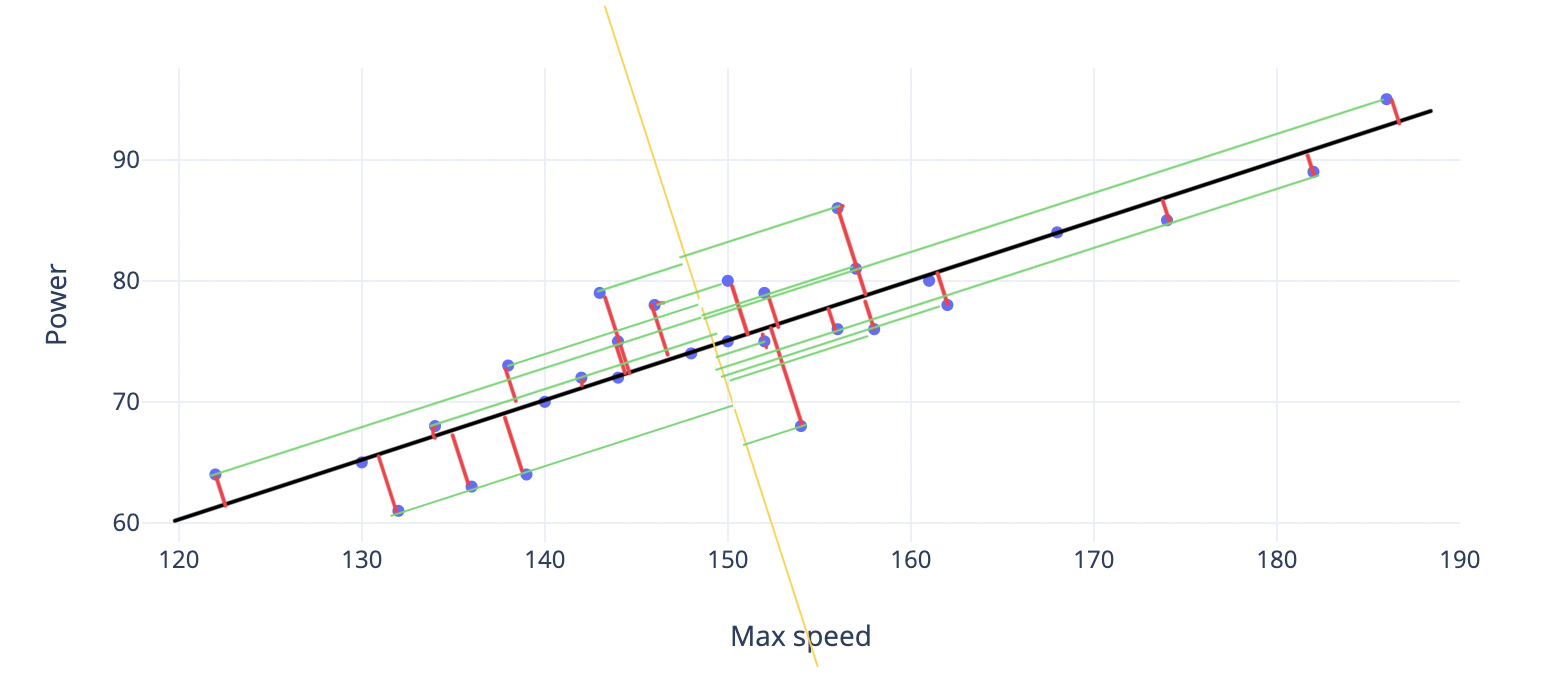

For getting the pricnipal companent 2 or the pc2 we draw a perpendicular from the pc1
- in pca all the principal components are perpendicular to each other
- because this is a 2d data we only have one possible way to get it
- now the yellow line is our PC2 projecting the points on this will give us the remaning information.


### Variation explained

$Variation =\frac{SS (distance) for that PC}{n-1}$


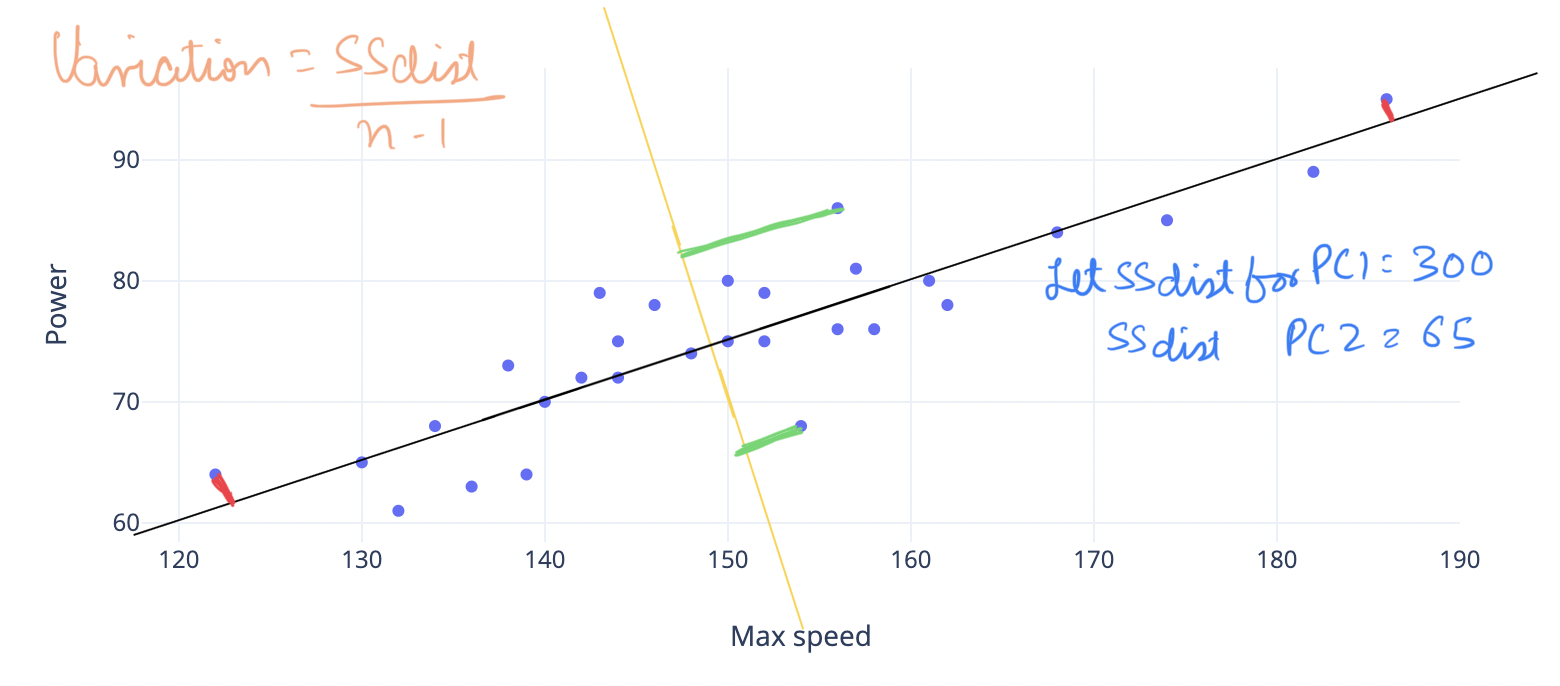

- we have marked the two farthest points for pc1 with red
- and the two farthest point for pc2 with green
- the distance from the origin to those is the squared distance for those points
- we calculate the sum of squared distance for all the points and then the variation
- we can easily see that the sum of all sqaured distance for pc1 will be much higher than for pc2
- let **SS(distance)for PC1** be 300 and **SS(distance)for PC2** be 60 and let sample size or n be 31
- then variation for $PC1 = 300/30$ ie:10
- and variation for $PC2 = 60/30$ ie:2



total variation = 10+2 ie:12

- that means pc1 accounts for 10/12=0.83, or 83% of total data
- and pc2 accounts for 17% fo the total data

so if we used just pc1 we could have represented 83% of total data.
- the first pc represents the highest amount of data and each PC represents less data than the one before it
- when the dimensions are a lot then we can use this to see how much dimensions we need.

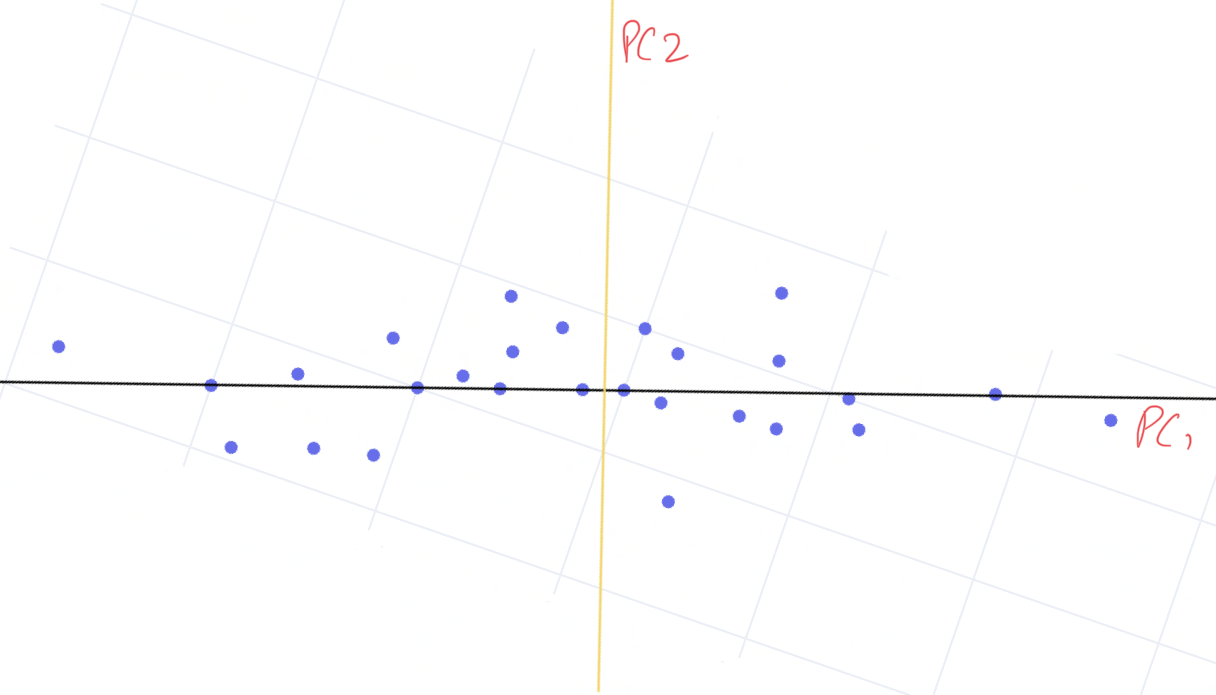

These are our new features or dimensions

### Reduce Dimensionality

In our example we just had two dimensions, but we can have a lot more than this, where we actually want to use this

Since the percentage of the overall variance explained declines with every new principal component, we can reduce dimensionality further by eliminating the least important principal components. At this stage, we have to decide how many principal components are sufficient and how much information loss we can tolerate.

Let say that we have a dataset with 100 dimensions that is we have 100 columns
- Now for column 1 we represent it as feature 1 thus we'll have features from f1 to f100
- Next if we rotate one feature let say f1 such that it lies along the maximum variation all the other features from f2 to f100 will also change
- Thus we'll have new feature dimension from f1' to f2'
- Next we can compute the sum of squared distances along each feature and divide it by the number of data points to get the varation around each PC
- Next we'll varaiation explained for each PC by the total varation explained by all the PCs which will help us get to the percentage of variation explained by each PC
- Now Let say that variation explained at PC1= 80%, at PC2 is 10%, PC3=1%, PC4=0.6% and so on

**Question: In the above given case after getting the percentage of variance explained around each PCs how many columns would it be better to have?**
- we can have 2 to 3 columns based on business logic that is if the business wants to retain 91% of the information after projection that we can go with first 3 PC and if they are fine with only 80% of infomration retained after projection then we can go with only the first PC.

#### **Scree plot**

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/067/343/original/15554174747084_pca3_1.png?1709699419)

- The blue bars show the percentage variance explained by each principal component.  The red line shows the cumulative sum.
- From the scree plot we can read off the percentage of the variance in the data explained as we add principal components. So the first principal component explains 32% of the variance of the data set. The first 2 principal components explain 56%, the first 3 explain 71%, and so on.

### Using PCA - Code walkthrough
for dimensionality reduction and Visualization.


We have a dataset of breast cancer classification that has 33 columns. visualizing the data is not possible with such high dimension

Breast cancer (BC) is one of the most common cancers among women worldwide, representing the majority of new cancer cases and cancer-related deaths according to global statistics, making it a significant public health problem in today’s society.

The early diagnosis of BC can improve the prognosis and chance of survival significantly, as it can promote timely clinical treatment to patients. Further accurate classification of benign tumors can prevent patients undergoing unnecessary treatments.

we'll use pca to reduce the dimensions to 2

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

In [ ]:
data_url = 'https://raw.githubusercontent.com/pkmklong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/master/data.csv'

In [ ]:
df = pd.read_csv(data_url)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.drop(['Unnamed: 32', 'id'], axis = 1, inplace = True)

In [ ]:
X = df.iloc[:, 1:].values
y = df['diagnosis'].values


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_sc = sc.fit_transform(X)


#### code implimenation using slearn

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_sc)

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))


Explained variation per principal component: [0.44272026 0.18971182]


explained variance is the amount of variance explained by each of the selected components.

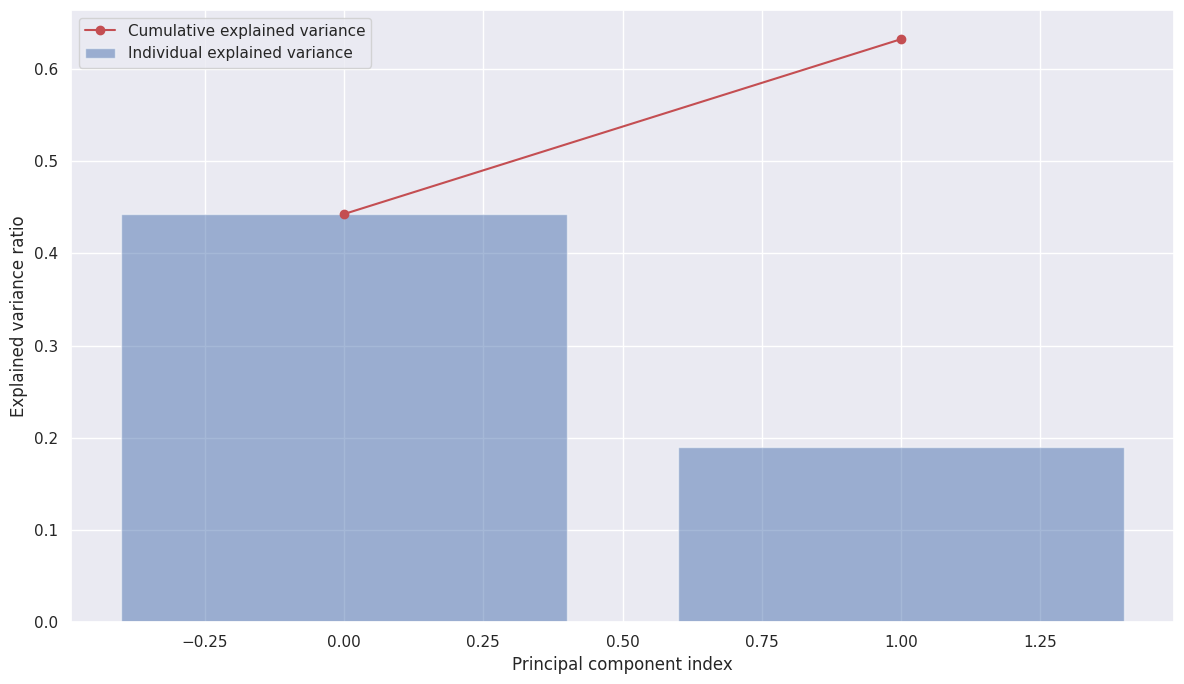

In [ ]:
# Determine explained variance using explained_variance_ration_ attribute
#
exp_var_pca = pca.explained_variance_ratio_
#
# Cumulative sum of eigenvalues; This will be used to create step plot
# for visualizing the variance explained by each principal component.
#
cum_sum = np.cumsum(exp_var_pca)
#
# Create the visualization plot
# Create the bar plot for individual variances
plt.figure(figsize=(12, 7))
plt.bar(range(0,len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.plot(range(0,len(cum_sum)), cum_sum, marker='o', linestyle='-', color='r',label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
df_pca=pd.DataFrame(X_pca)

In [ ]:
df_pca['y']=y
df_pca.head()

,0,1,y
0,9.192837,1.948583,M
1,2.387802,-3.768172,M
2,5.733896,-1.075174,M
3,7.122953,10.275589,M
4,3.935302,-1.948072,M


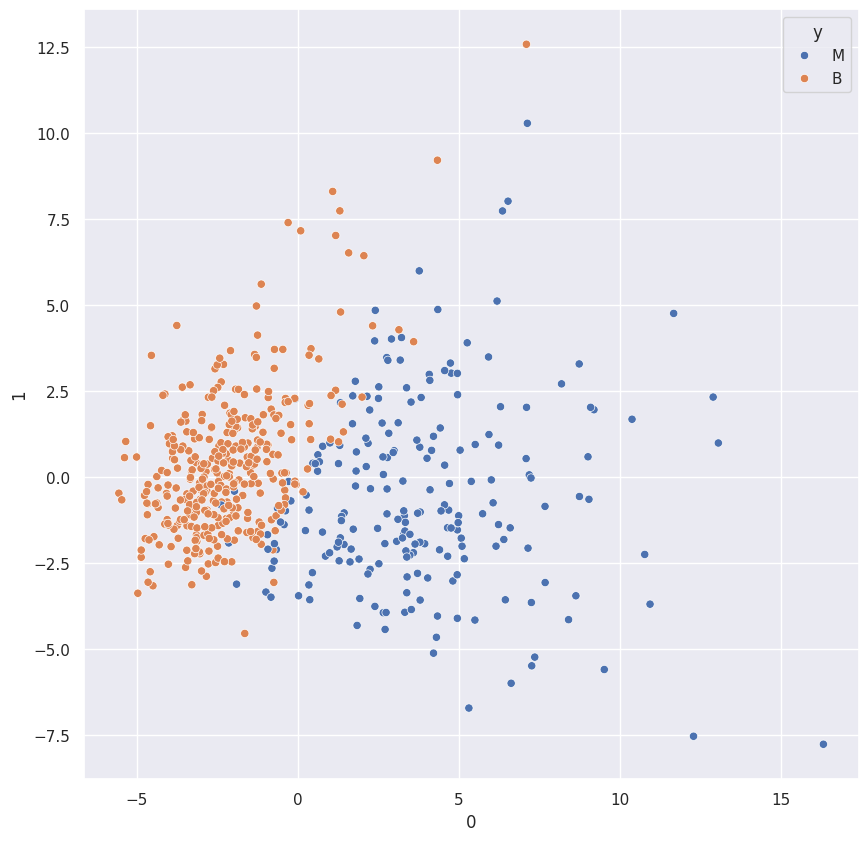

In [ ]:
plt.figure(figsize = (10,10))
sns.scatterplot(x = 0, y = 1,hue ='y',data=df_pca)
plt.show()

In [ ]:
X.shape

(569, 30)

### PCA limitations


1. **Low interpretability of principal components** Principal components are linear combinations of the features from the original data, but they are not as easy to interpret. For example, it is difficult to tell which are the most important features in the dataset after computing principal components.
2. **PCA assumes a linear relationship between features** The algorithm is not well suited to capturing non-linear relationships.
3. **PCA is sensitive to the scale of the features** Imagine we have two features - one takes values between 0 and 1000, while the other takes values between 0 and 1. PCA will be extremely biased towards the first feature being the first principle component, regardless of the actual maximum variance within the data. This is why it’s so important to standardize the values first.
4. **PCA is not robust against outliers** Similar to the point above, the algorithm will be biased in datasets with strong outliers.

## t-SNE

 t-Distributed Stochastic Neighbor Embedding unlike Principal Component Analysis (PCA) is a non-linear method used for visualizing higher dimensional data in human interpretable dimensions like 2D or 3D.

Stochastic → not definite but random probability

Neighbor →concerned only about retaining the variance of neighbor points

Embedding → plotting data into lower dimensions


t-SNE tries to preserve the neighborhood of the points even when they are being transformed from higher dimensions to lower dimensions. The algorithm figures out the points that are close to each other and the ones that are farther away. The neighborhood, i.e, the cluster with points close to each other are preserved and this holds well even if there are multiple clusters. However, the distance between the clusters is not preserved after transformation.

t-SNE tries to figure out how similar the points are and groups them based on their similarity and is therefore able to preserve the inner structure of the data.


https://distill.pub/2016/misread-tsne/

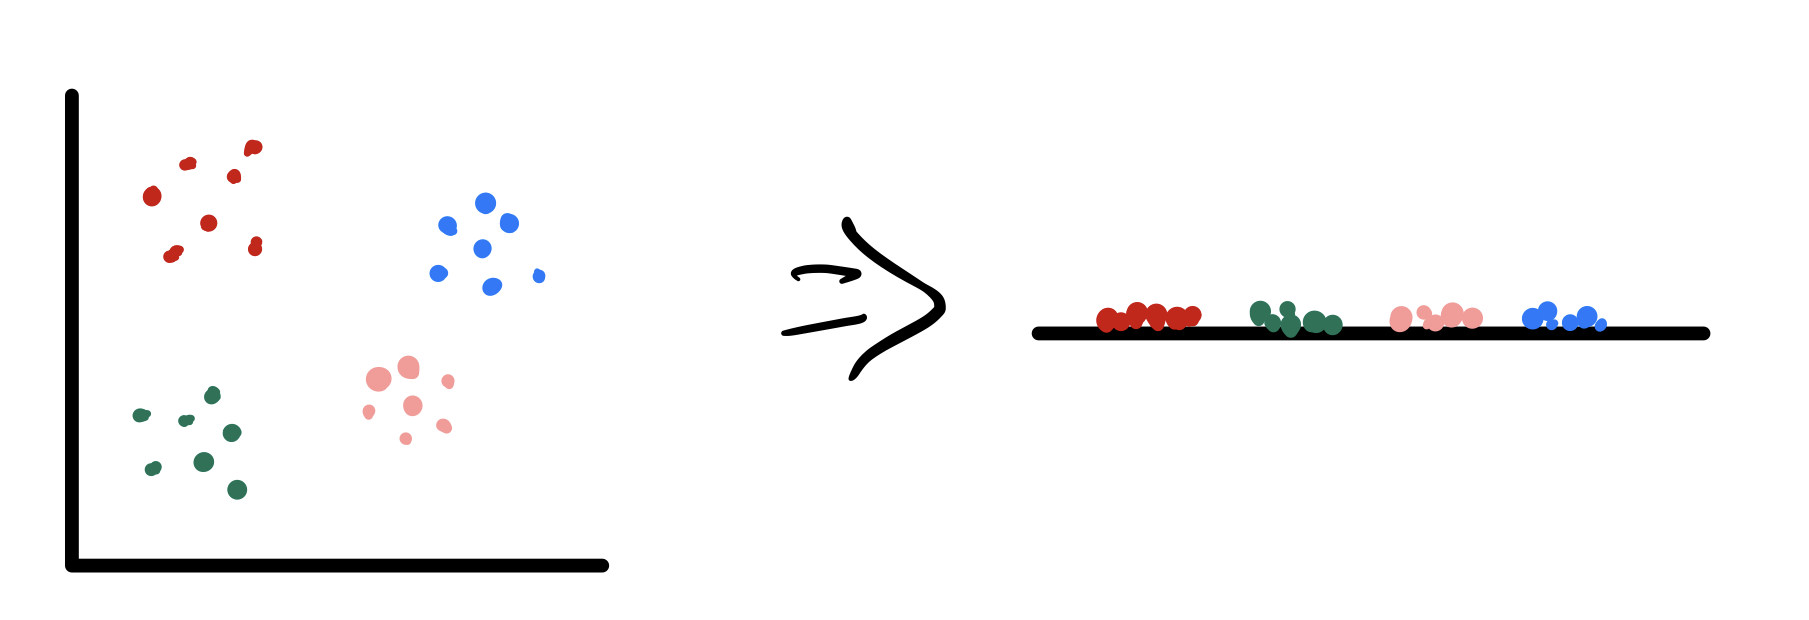

- The t-SNE algorithm models the probability distribution of neighbors around each point,it uses normal distribution (in higher dimension) and t-Distribution (in lower dimension) to reduce the dimensions of the dataset.
- Here, the term neighbors refers to the set of points which are closest to each point. The goal of the procedure is to find a mapping onto the 2-dimensional space that minimizes the differences between these two distributions over all points.

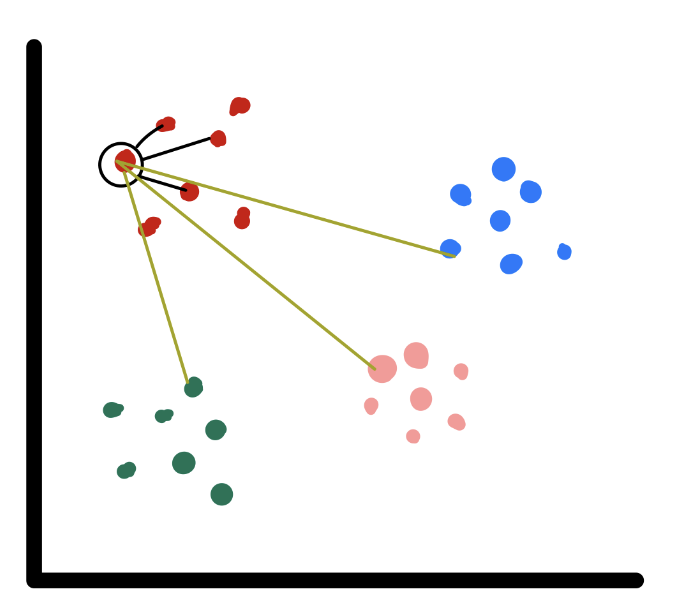

> T-distribution [**Optional content can briefly covery it**]

T-distribution is similar to normal distribution except that it has a thicker and longer tail. Normal distribution has just the normal shape which means it drops to 0 after few standard deviations from the center whereas t-distribution is any member of a family of continuous probability distributions that arise when estimating the mean of a normally distributed population in situations where the sample size is small and the population's standard deviation is not known

- The T distribution is a continuous probability distribution of the z-score when the estimated standard deviation is used in the denominator rather than the true standard deviation.
- The T distribution, like the normal distribution, is bell-shaped and symmetric, but it has heavier tails, which means it tends to produce values that fall far from its mean.

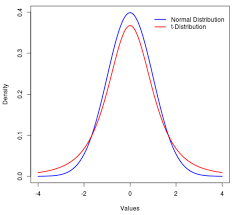

t distribution is used instead of normal distribution because it has more room to place points without getting to zero
 - t distribution with DOF 1 is used because that has the fattest/tallest tail and will give us more room to place points
 - T-distributions is able to better differentiate the farther points relative to the query points due to their taller tails.

### Calculating probabilities

The probability distribution is defined for two points, A to B, as a conditional probability that A will pick B as its neighbor.

- The first stage of the algorithm is calculating the distances of each point from all of the other points.
- Then, taking these distances and transforming them into conditional probabilities using Normal distribution that represent the similarity between every two points.
- It means that we want to evaluate how similar every two points in the data are, or in other words, how likely they are to be neighbors.

So what we do here is choose a point and then build a normal curve with that point as the center (selecting the red point in this case). It is a 2d plot with each point represented on the x-axis. The height of each point on the curve is based on similarity, i.e., the more similar the point, the closer they are to the center and the more the value of the y axis. Here other red points are closure in similarity, so it is near the central point.

- The further a point is away from a query point, its distance would lie away from the peak of the curve. The points which lie near the peak would be considered the neighbors of the query point.

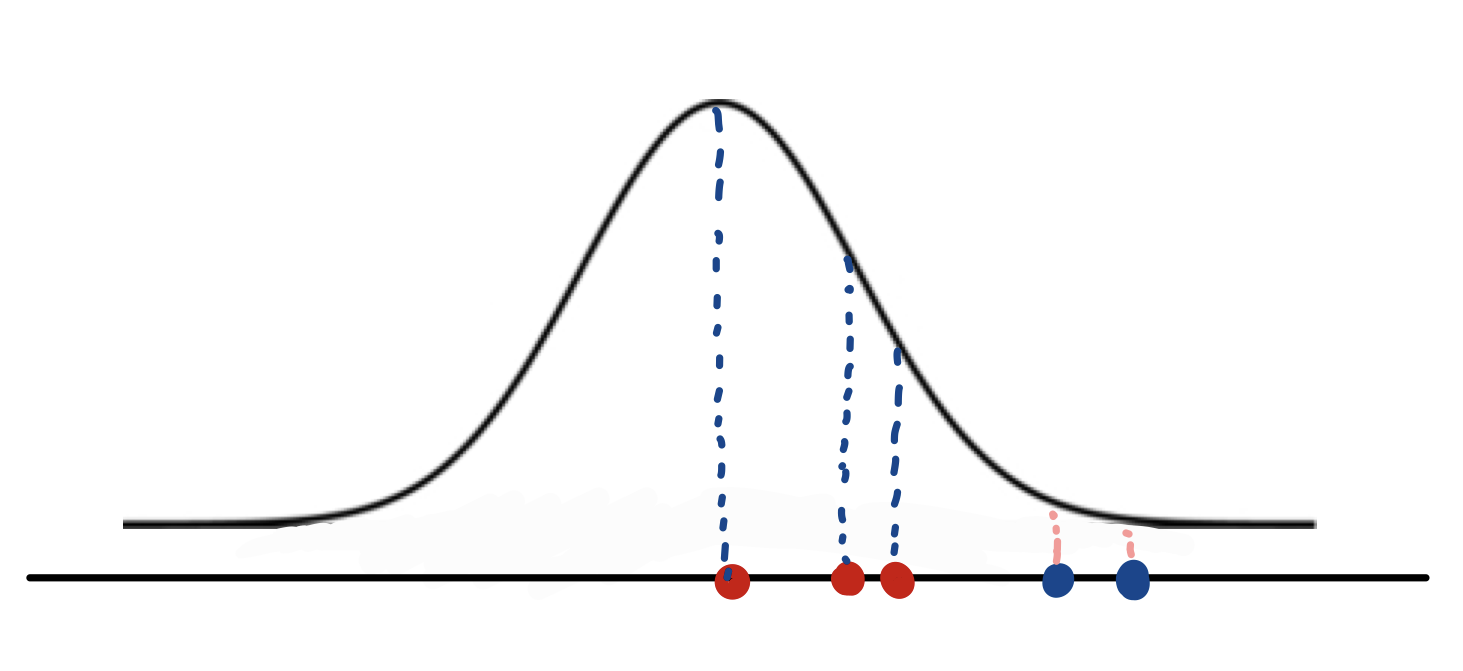

**Summary so far**
- In Higher Dimension

  - Step 1: Picks a data point (say P1), calculates its Euclidean distance from a neighboring data point (say P2) and converts this distance into the conditional probability using normal distribution.
    - Conditional probability represents the similarity between the pairs of data points.

- Step 2: Again it calculates the distance of P1 from other neighboring point (say P3) and does the same as in Step 1.

It keeps doing same thing for all the data points. In this way t-SNE keeps computing pairwise conditional probabilities for each data point using normal distribution in higher dimension.

### Similarity matrix

- We will plot the probabilities for all points
- taking one point then calculating for all other point
- then taking another point and calculating for all points


from the probabilities that we end up with a similarity matrix where we can see the points with high similarity scores, which means they belong to the same cluster.

- in the example bellow for just some point we have created the similarity matrix from the 2D plot
- in green we show higher similarity
- in white we show low similarity
- as we can see matrix defines the similarity of a point to itself(in grey), but it does not make any sense to do that, so t-SNE defines it as 0

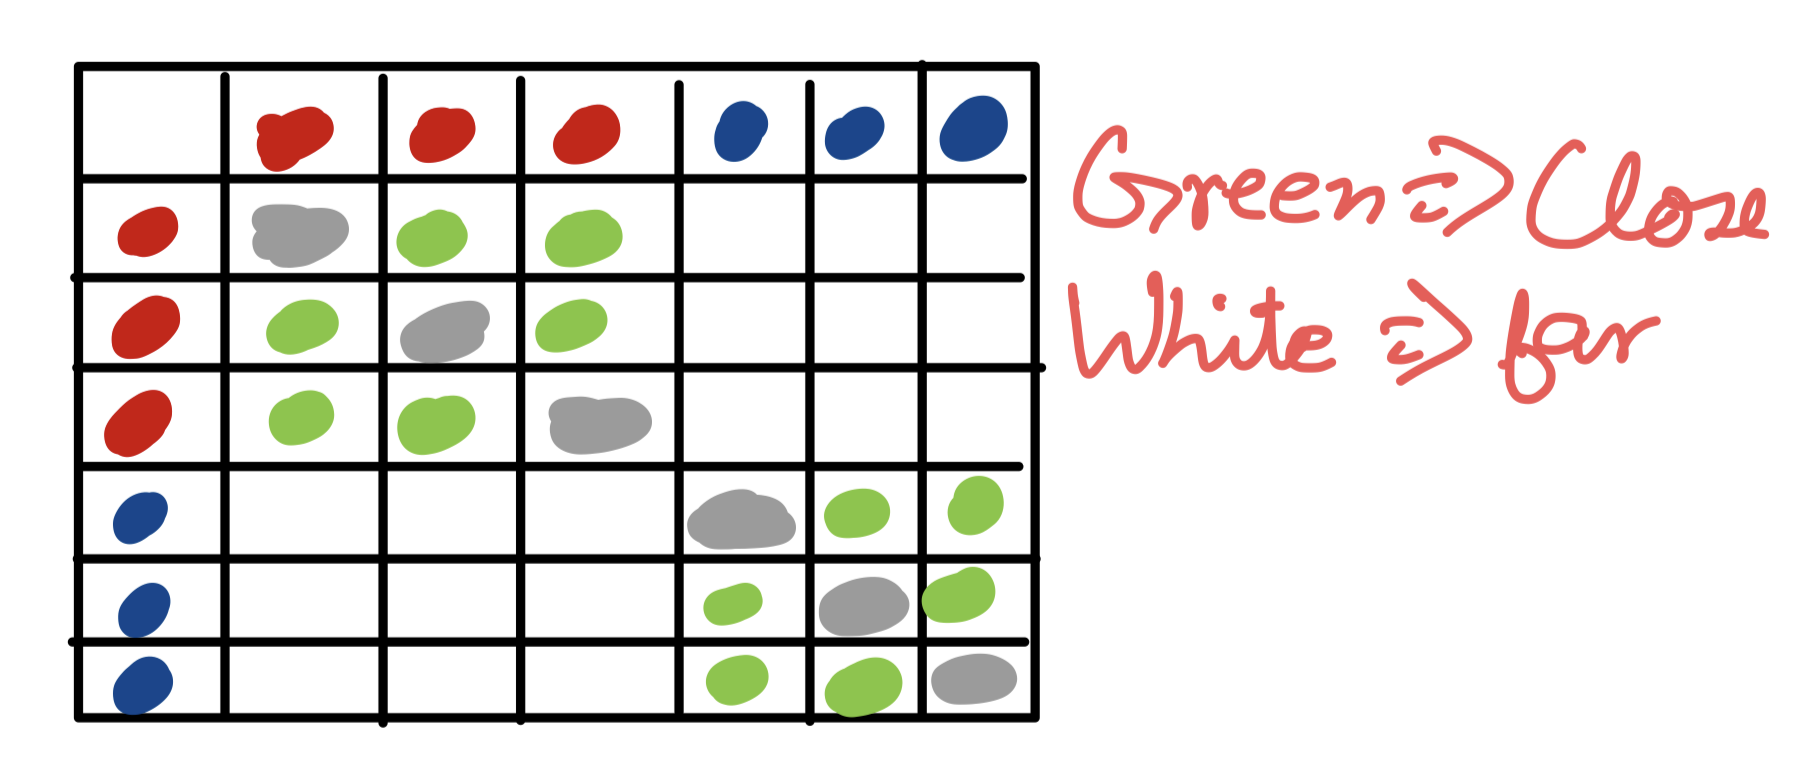

After we get the similarity matrix built we can now start with the actual dimensionality reduction from 2d to 1d in our example

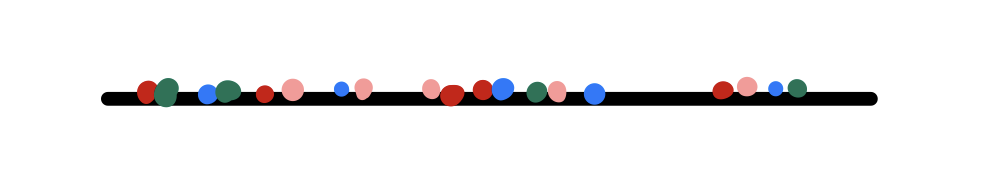

### Random initialization
We start by randomly placing points on a line

- we move them step by step such that points of similar charecterstics gather together and points of different charecterstics more far apart
- these points will move based on the similarity that we calculated

We plot the similarity matrix for our dimensionally reduced, i.e., 1D mappings in our case, and try to get a matrix similar to the original similarity matrix.


we again have a matrix of similarity scores for this 1d data but this is not correct
- below we have plotted the distance matrix for the same red and blue points
- based on their position on the 1D line we have filled the matrix

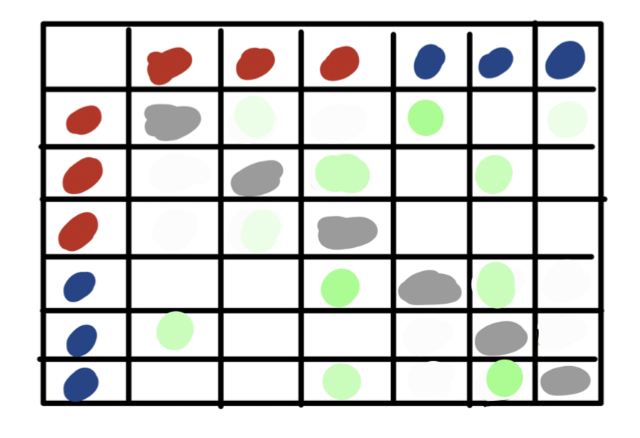

lets figure out where to move the first point
- should it move left or to the right


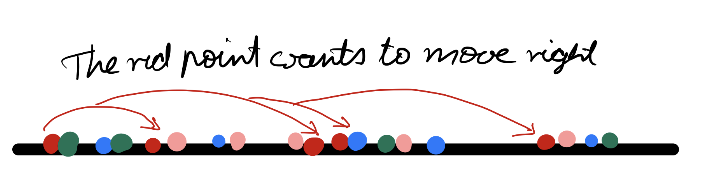

the red point should move right, but how do we know that
- we know that from the original similarity matrix that we had.
- itiration by itiration we will move points and update the matrix till we have a matrix that is smilar to what we had originally
- on each step it chooses a direction for each point to make the matrix like aur original matrix  

Using the 2D similarity matrix, we move the points on the line to the left or right and adjust them so that the similarity matrix of 1D becomes the same as 2D.

**change the dataset in the low-dimensional space so that the joint probability distribution representing it would be as similar as possible to the one in the high dimension**

So finally, we get the points as we should see, and similar characteristics points occur together.

**Summary so far**

Lower Dimension

- Step 3: t-SNE arranges all of the data points randomly on the required lower dimension (say two dimensional space).

- Step 4: It again does the same calculations for all the data points in the lower dimension as it did for all the data points in the higher dimension in Step 1 and Step 2. The only difference is that it uses t-Distribution in this case instead of normal distribution. That is why, it is called t-SNE instead of simple SNE.

It also creates a similarity matrix in lower dimension (say S2).

- Now t-SNE compares the similarity matrix S1 and S2 and tries to minimize the difference such that all the pairs have a similar probability distribution (both in higher and lower dimension).


### Crowding problem [**Optional if time permits**]

Let us try to map a 2-dimensional cluster to 1-dimensional. Take the 2-d map like corners of a square. let there be a, b, c, d 4 corners of the square. Now when you will try to preserve the neighborhood distance. if you will do it for a — b, b — c, c — d then you will not be able to preserve it for a — d. Here arises the problem which is called a Crowding Problem.

More formally It is impossible to preserve all neighborhood distances when we map from a higher dimension to lower dimension is referred to Crowding Problem

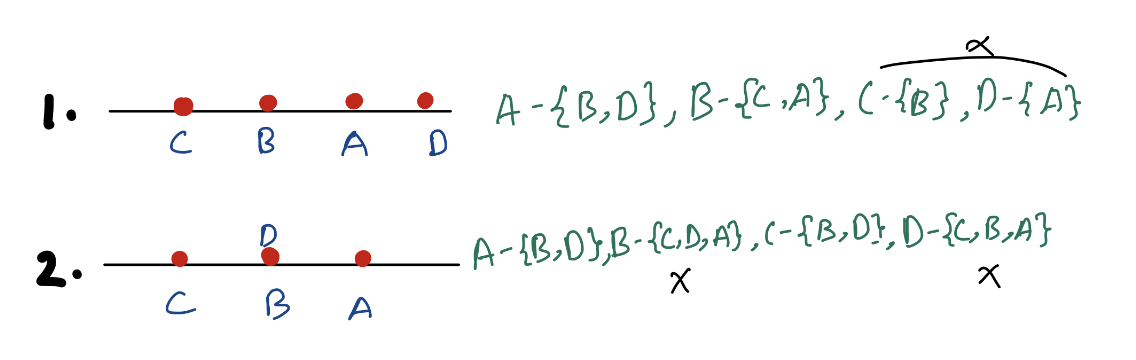

this is the crowding problem of tsne.
- the preservation of neighborhood need to happen for all the points
- Sometimes, it is impossible to preserve the distance in all neighborhood(N). Such a problem is called Crowding problem.

Earlier, Stochastic Neighborhood Embedding (SNE) is used for dimensional reduction they often end up with Crowding problem so, t-SNE were introduced to overcome this problem. t-SNE doesn't guaranty to resolve the crowding problem all the times
- by the use of t distribution we try to improve the situation a bit because it gives us more room to place the points on the plot
- it does not remove it completely but hepls to overcome the crowding problem and preserving the neighborhood distance.

### Perplexity

The main parameter controlling the fitting is called perplexity. Perplexity is roughly equivalent to the number of nearest neighbors considered when matching the original and fitted distributions for each point. A low perplexity means we care about local scale and focus on the closest other points. High perplexity takes more of a "big picture" approach.

if we assume perplexity = 5 then for each point the algorithm will preserve the distance of its first 5 neighborhood points and will leave the others. You must try a different number of perplexity values while training but never make it equal to the number of data points.
- Consider the number of clusters that are expected and the number of observations when setting this value.The original paper suggests a perplexity between 5-50



In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2x, random_state = 0)
X_tsne = tsne.fit_transform(X_sc)

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


In [ ]:
X_tsne.shape

(569, 2)

In [ ]:
df_tsne=pd.DataFrame(X_tsne)

In [ ]:
df_tsne['y']=y
df_tsne.head()

,0,1,y
0,-21.797403,26.834538,M
1,-20.794983,11.857209,M
2,-22.553238,20.898771,M
3,-5.771139,26.431589,M
4,-17.506866,17.087984,M


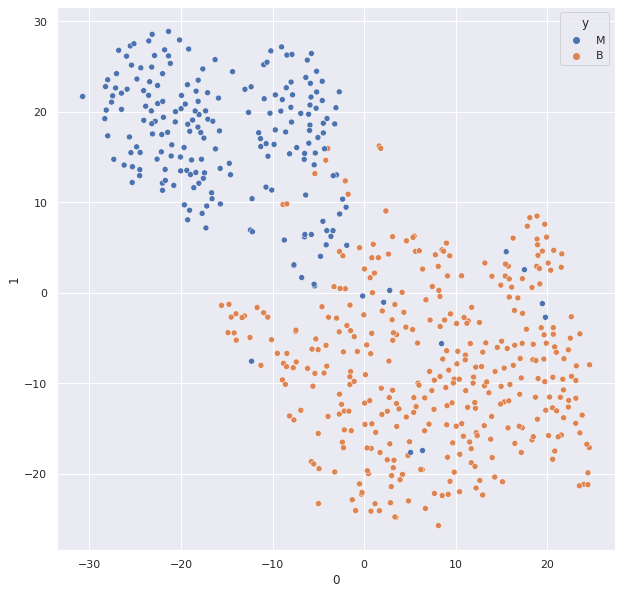

In [ ]:
plt.figure(figsize = (10,10))
sns.scatterplot(x = 0, y = 1,hue ='y',data=df_tsne)
plt.show()

### tsne limitation

1. First, unlike PCE, t-SNE doesn't give an explicit transformation that you can reuse. So, if you have obtained some new data, the entire optimization has to start from the beginning.

2. This is a problem because t-SNE can be really slow. For n data points, two n x n matrices are constructed and used. The gradient also involves a summation, which puts even more computational load.

3. Another issue with t-SNE is that it is not deterministic. Running the algorithm two times will yield two different results. Because of this, reading a t-SNE plot can be like reading tea leaves.